# Mixture of Mixture of Gaussians Example

In [231]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

# Set Parameters

In [232]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = 1

# Generate Data

In [233]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(0,3,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

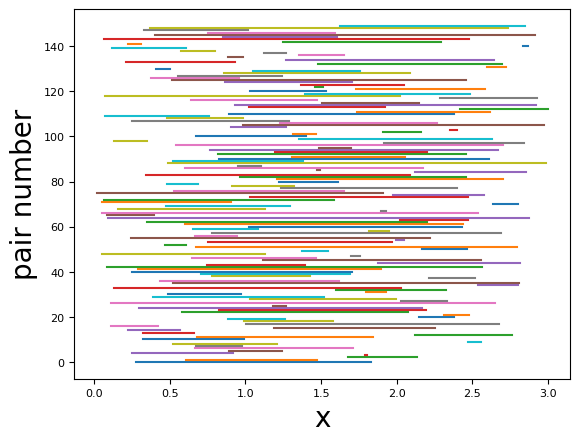

In [234]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Linear

In [235]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = 5*X[component_ids==0] -4
Y[(component_ids==1)] = -2*X[component_ids==1] + 5
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

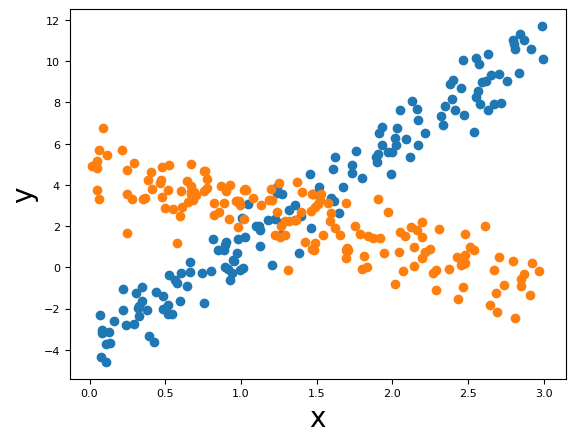

In [236]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
plt.xlabel("x")
plt.ylabel("y")
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=8)    # fontsize of the tick labels
plt.rc('ytick', labelsize=8)    # fontsize of the tick labels
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

Text(0.5, 0, 'x')

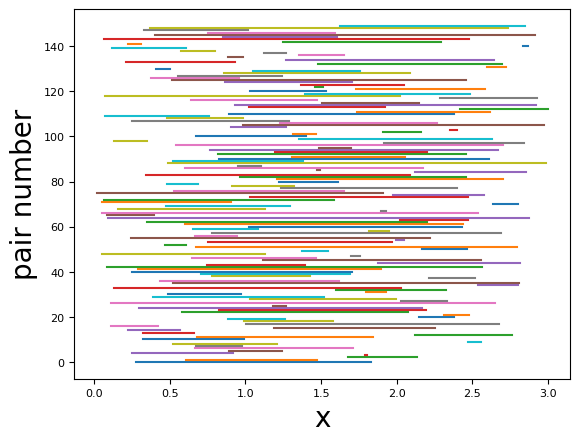

In [237]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Nonlinear

In [238]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = X[component_ids==0]**2 
Y[(component_ids==1)] = -X[component_ids==1]**2
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

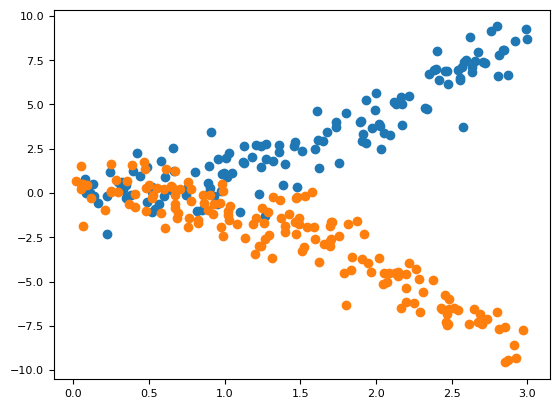

In [239]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [240]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [241]:
# # define model
# model = MyNN()

# for em_iter in range(T):

#     # E-step
#     gamma = compute_responsibilities(...)

#     # M-step (train NN with weights gamma)
#     for step in range(k):
#         preds = model(x)
#         loss = weighted_loss(preds, y, gamma)
#         loss.backward()
#         optimizer.step()


In [242]:
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Simple feedforward network
# -------------------------
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# -------------------------
# Weighted loss
# -------------------------
def weighted_mse(pred, target, weights):
    # pred: (n, d)
    # target: (n, d)
    # weights: (n,)
    loss = (pred - target)**2
    loss = loss.mean(dim=1)        # per-sample loss (n,)
    return (weights * loss).sum() / weights.sum()


# -------------------------
# E-step (example placeholder)
# -------------------------
# def compute_responsibilities(X, Y, w, models):
#     X = torch.tensor(X, dtype=torch.float32)
#     Y = torch.tensor(Y, dtype=torch.float32)
#     # returns gamma: (n, M)
#     # You’ll replace this with your actual model likelihoods
#     n = X.shape[0]
#     M = len(models)
#     gamma = np.zeros((n,M))
#     # gamma = torch.ones(n, M) / M
#     for im in range(M):
#         mu = models[im](X)
        
#         Delta = (Y - mu)**2 #square loss for each observation for each component
#         #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#         Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
#         R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
#         gamma[:,im] = R

#     return torch.tensor(gamma, dtype=torch.float32)

def compute_responsibilities(x, Y, w, models, noise_sd):
    x = torch.tensor(x, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)
    
    n = x.shape[0]
    M = len(models)
    
    gamma = torch.zeros((int(n), int(M)), dtype=torch.float32)
    
    w_tensor = torch.tensor(w, dtype=torch.float32)
    log_probs = []

    for im in range(M):
        mu = models[im](x)
        
        Delta = (Y - mu)**2
        log_likelihood = -Delta / (2 * noise_sd**2)
        
        log_prior = torch.log(w_tensor[im])
        
        log_probs.append(log_likelihood.squeeze() + log_prior)

    log_probs = torch.stack(log_probs, dim=1)

    gamma = torch.softmax(log_probs, dim=1)
    
    # for im in range(M):
    #     mu = models[im](x)               # shape (n, d)

    #     print("Mu", mu[-1:-10])
    #     # Delta = (Y - mu)**2               # per-sample squared error
        
    #     # # example of pairing and weighting in PyTorch
    #     # Delta_pairs = Delta[0::2] + Delta[1::2]        # adjust if d != 2
    #     # Delta_exp = torch.exp(Delta_pairs)
        
    #     # const_term = torch.exp(torch.tensor(1/(2*noise_sd**2), dtype=torch.float32))
    #     # Delta_weighted = (const_term + Delta_exp) * w_tensor
        
    #     # # normalize to sum to 1 per row (soft assignment)
    #     # R = Delta_weighted / torch.sum(Delta_weighted)
    #     # gamma[:, im] = R
    #     Delta = (Y - mu)**2             # shape (n,1)
    #     print("y-mu", Delta[0,:])
    #     Delta_weighted = (torch.exp(torch.tensor(1/(2*noise_sd**2), dtype=torch.float32)) + torch.exp(Delta)) * w_tensor
    #     print("delta_weighted", Delta_weighted[0,:])
    #     gamma[:, im] = (Delta_weighted / Delta_weighted.sum(dim=0))[:,0]
    #     print("gamma:", gamma[0,:])

    return gamma


kern_width = 0.8

K = gauss_kernal_mat(X,X,sigma=kern_width)
# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))


# -------------------------
# Main EM loop
# -------------------------

def EM_train(x, y, M, em_iters=10, inner_steps=10):
    n, d = x.shape
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # initialize models + optimizers
    models = [Net(d, 32, y.shape[1]) for _ in range(M)]
    opts = [optim.Adam(m.parameters(), lr=1e-3) for m in models]

    for em_iter in range(em_iters):

        # -----------------
        # E-step
        # -----------------
        gamma = compute_responsibilities(x, y, w, models, noise_sd)  # (n, M)
    

        # Delta = (Y - K@A)**2 #square loss for each observation for each component
        # #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
        # Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
        # R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
        
        # log_probs = []

        # for im in range(M):
        #     mu = models[im](x)
        #     log_p = -(y - mu)**2 / (2 * noise_sd)
        #     log_probs.append(log_p)

        # log_probs = torch.stack(log_probs, dim=1)  # (n, M)

        # gamma = torch.softmax(log_probs, dim=1)
    
        # -----------------
        # M-step
        # -----------------
        for m in range(M):
            model = models[m]
            opt = opts[m]

            weights = gamma[:, m].detach()  # (n,)

            for _ in range(inner_steps):
                opt.zero_grad()

                pred = model(x)
                loss = weighted_mse(pred, y, weights)

                loss.backward()
                opt.step()

        # print(f"EM iter {em_iter} done")

    return models

In [243]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

models = EM_train(X_tensor, Y_tensor, M=2, em_iters=100, inner_steps=100)

C:\Users\jj\AppData\Local\Temp\ipykernel_34384\1843046537.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_34384\1843046537.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_34384\1843046537.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_34384\1843046537.py:58: UserWarning: To copy 

In [244]:
# kern_width = 0.8

# K = gauss_kernal_mat(X,X,sigma=kern_width)
# # transformer = KernelCentere
# #r().fit(K)
# # K = transformer.transform(K)
# w, A = scipy.sparse.linalg.eigs(K, k=M)
# w = np.real(w)
# A = np.real(A)
# w = w/np.sum(w)
# maxiter = 30

# R = np.zeros((n,M))

# for i in range(maxiter):
#     print(i)
#     # E-step
#     Delta = (Y - K@A)**2 #square loss for each observation for each component
#     #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#     Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
#     R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    
#     # M-step
#     w = np.sum(R,axis=0) / n
#     for j in range(M):
#         Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
#         #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
#         print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))


In [245]:
print(R)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

In [246]:
Rprime = copy(R)
Rprime[R<0.01] = 0
Rprime[R>0.99] = 1
print(Rprime)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

# Check out the results

In [247]:
# Y_hat = np.zeros((2*n,M))
# for j in range(M):
#         #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
#         Y_hat[:,j] = K@A[:,j]

[0.22436506 0.22493349 0.22550195 0.2260705  0.22663894 0.22720726
 0.22777574 0.22834426 0.22891273 0.2294812  0.23004976 0.23061824
 0.23118666 0.23175505 0.23232356 0.23289213 0.23346049 0.234029
 0.2345975  0.23516597 0.2357344  0.23630282 0.23687135 0.2374398
 0.23800835 0.23857683 0.2391453  0.2397137  0.24028221 0.24085066
 0.24141912 0.24198768 0.24255617 0.2431246  0.24369308 0.24426147
 0.24483    0.24539849 0.24596697 0.2465354  0.24710388 0.2476724
 0.24824083 0.24880934 0.24937779 0.24994624 0.25051475 0.25108325
 0.25165164 0.2522201  0.25278857 0.25335705 0.25392544 0.25449395
 0.25506258 0.25563103 0.25619945 0.25676787 0.25733638 0.25790492
 0.2584734  0.2590418  0.25961024 0.2601787  0.26074716 0.26131558
 0.2618841  0.26245263 0.26302108 0.26358956 0.2641581  0.2647266
 0.26529494 0.26586348 0.266432   0.2670005  0.2675689  0.2681374
 0.26870576 0.26927418 0.26984268 0.27041122 0.2709798  0.27154827
 0.27211672 0.27268517 0.27325347 0.273822   0.2743905  0.27495903
 

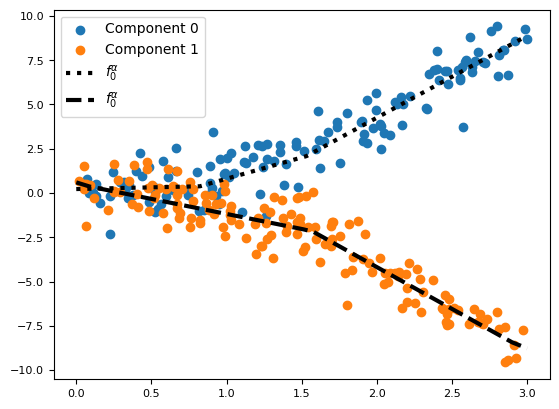

In [248]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(0,3,1000), (1000,1))
xx_tensor = torch.tensor(xx, dtype=torch.float32)
# Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
# Yhat = Ktest@A
Yhat_tens = torch.zeros((xx_tensor.shape[0], M), dtype=torch.float32)  # tensor instead of np.zeros

for m in range(M):
    # forward pass
    Yhat_tens[:, m] = models[m](xx_tensor).squeeze()

Yhat = Yhat_tens.detach().numpy()

print(Yhat[:,0])
print(Yhat[:,1])
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

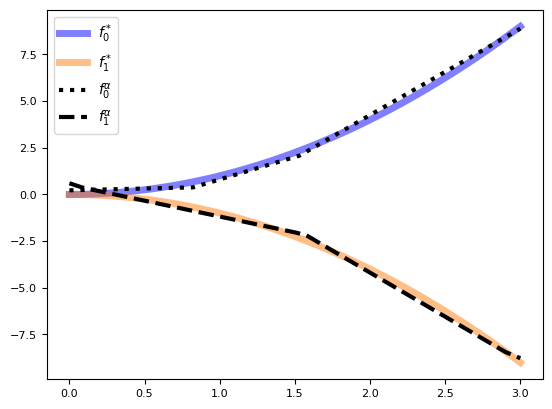

In [249]:
plt.plot(xx, xx**2, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


In [250]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Y_hat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Y_hat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

NameError: name 'Y_hat' is not defined

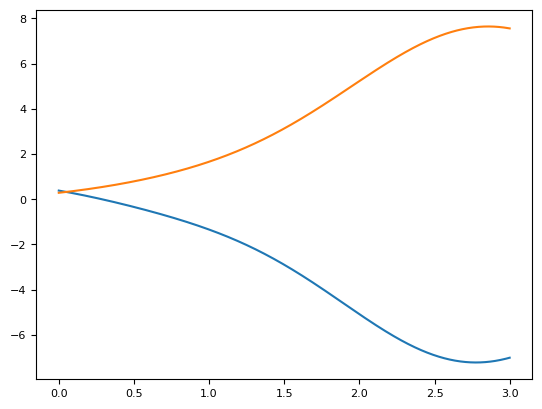

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])